# Inspecting matches in video

The DSL tells you *where* in the corpus a scenario happens.
This notebook closes the loop: given a match, pull the
original video from the Physical AI AV Dataset on HuggingFace,
decode frames over the match's interval, and view them
alongside the `ContextWindow` snapshot.

Pipeline:

1. Run a DSL query and pick a match.
2. Prefetch the clip's video and egomotion from HF with
   `ds.download_clips`.
3. Build a `Sequence` and decode frames sampled across the
   match interval.
4. Show what else was annotated during the window.

> Requires the optional `hf` extra (`uv sync --extra hf`) plus
> the notebook tooling (`--group notebooks`). The first
> download pulls a few hundred MB per clip and can take
> 5–15 seconds depending on your link.


## Setup


In [1]:
import os
from pathlib import Path

import numpy as np

from cascade_av.dataset import CascadeDataset

# --- shared notebook styling -----------------------------------------------
import matplotlib.pyplot as plt
import pandas as pd

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.titleweight": "semibold",
    "axes.labelsize": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.linestyle": "--",
    "grid.alpha": 0.35,
    "figure.dpi": 110,
    "savefig.dpi": 110,
})

pd.options.display.max_colwidth = 110
pd.options.display.width = 140
pd.options.display.float_format = "{:.2f}".format


In [2]:
ds = CascadeDataset(Path(os.environ["CASCADE_AV_DATASET_ROOT"]))
print(f"corpus loaded — {len(ds)} clips")


corpus loaded — 305 clips


/home/horde/Projects/av-causal-dataset-tools/src/cascade_av/dataset.py:118: UserWarning: 1 clip_id(s) had multiple annotation files; kept first by filename. (Set CASCADE_AV_VERBOSE=1 for per-file detail.)
  self._scan(annotation_paths, annotation_root)


## 1. Find a match

Pick a scenario with a tight temporal window. `while` and
`then` produce matches whose interval is the actual moment
both conditions held — ideal for video inspection.


In [3]:
query = "agent.type = ped while ego.action = decel"
matches = ds.find(query)
print(f"{len(matches)} matches for: {query}")

m = matches.matches[0]
print(f"chosen match: clip {m.clip_id}  "
      f"window {m.interval.start:.2f}–{m.interval.end:.2f}s")


35 matches for: agent.type = ped while ego.action = decel
chosen match: clip a9167a89-a730-437a-b07f-893b3949fefc  window 13.00–13.30s


## 2. Prefetch the clip from HuggingFace

`ds.download_clips` accepts an iterable of clip ids and pulls
the canonical camera plus egomotion (the minimum needed to
build a `Sequence`). Files are cached locally — re-running
is a no-op.


In [4]:
ds.download_clips([m.clip_id])


Downloading: 100%|##########| 1.22G/1.22G [00:00<?, ?B/s]

Fetching 2 files (2 cached):   0%|          | 0/2 [00:00<?, ?it/s]

## 3. Decode frames across the match window

`seq.video.decode_images_from_timestamps` takes microsecond
timestamps as an `int64` array. We sample uniformly across
the match interval.


clip duration: 20.13s   fps: 30.0


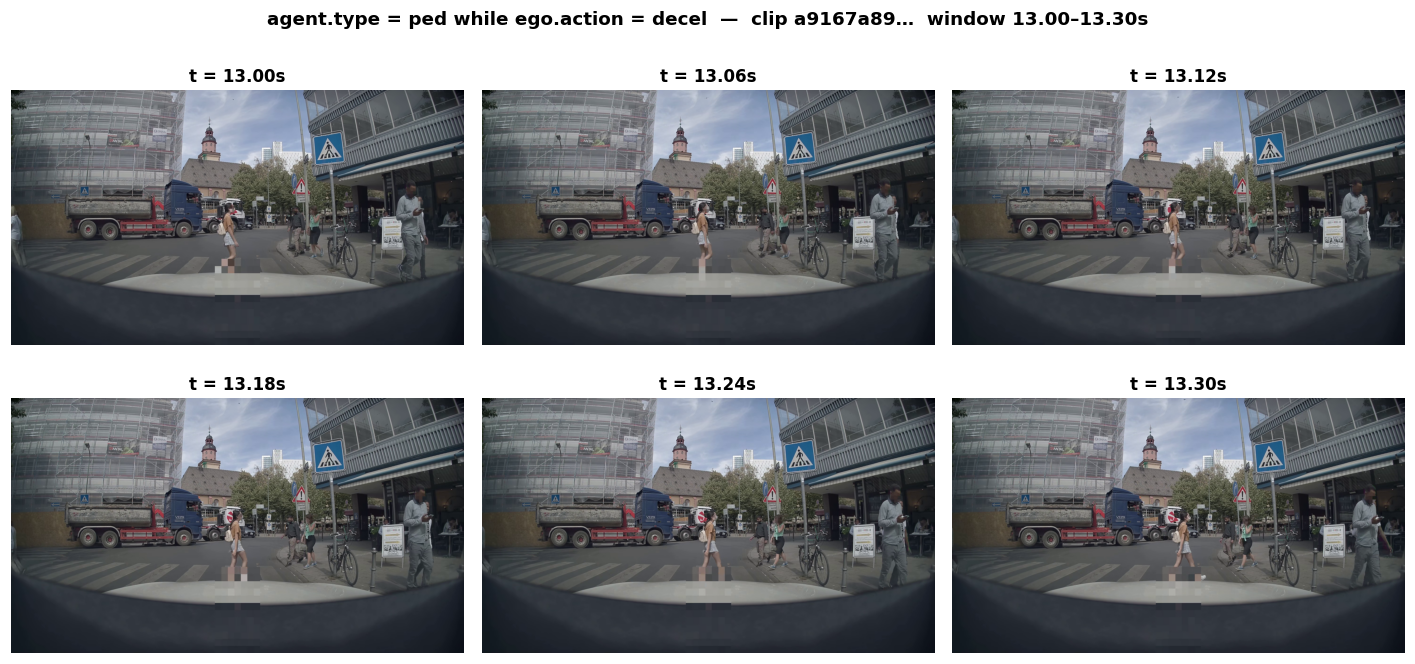

In [5]:
seq = ds.get_sequence(m.clip_id)
print(f"clip duration: {seq.duration_s:.2f}s   fps: {seq.fps}")

n_frames = 6
t_seconds = np.linspace(m.interval.start, m.interval.end, n_frames)
t_us = (t_seconds * 1_000_000).astype(np.int64)
images, _ = seq.video.decode_images_from_timestamps(t_us)

fig, axes = plt.subplots(2, 3, figsize=(13, 6.5))
for ax, img, t in zip(axes.ravel(), images, t_seconds):
    ax.imshow(img)
    ax.set_title(f"t = {t:.2f}s", fontsize=11)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.grid(False)
    for spine in ax.spines.values():
        spine.set_visible(False)
fig.suptitle(
    f"{query}  —  clip {m.clip_id[:8]}…  window "
    f"{m.interval.start:.2f}–{m.interval.end:.2f}s",
    fontsize=12, fontweight="semibold",
)
plt.tight_layout()
plt.show()


## 4. What else was happening?

Pair the frames with `ds.context_for(m)` — the same window
seen through the annotation lens.


In [6]:
ctx = ds.context_for(m)

pd.DataFrame([
    ("clip_id",        ctx.clip_id),
    ("window",         f"{ctx.interval.start:.2f}–{ctx.interval.end:.2f}s"),
    ("agents",         len(ctx.agents)),
    ("ego actions",    [ea.type for ea in ctx.ego_actions]),
    ("environments",   [e.type for e in ctx.environments]),
    ("light states",   len(ctx.light_states)),
    ("traffic objects", [o.type for o in ctx.traffic_objects]),
], columns=["field", "value"])


,field,value
0,clip_id,a9167a89-a730-437a-b07f-893b3949fefc
1,window,13.00–13.30s
2,agents,4
3,ego actions,"[oxd:Stop, oxd:Decelerate]"
4,environments,"[oxd:Road, oxd:Sidewalk, oxd:PedestrianCrossing, oxd:YIntersection]"
5,light states,0
6,traffic objects,"[Other, Other oxd:TrafficSign, oxd:WarningSign]"


In [7]:
pd.DataFrame([
    {
        "id":         a.agent.id,
        "type":       a.agent.type,
        "visible":    f"{a.visibility.start:.2f}–{a.visibility.end:.2f}s",
        "actions":    [ax.action_type for ax in a.actions],
    }
    for a in ctx.agents
])


,id,type,visible,actions
0,Agent3,Pedestrian (Adult),13.00–13.30s,[oxd:Walk]
1,Agent4,Pedestrian (Adult),13.00–13.30s,[oxd:Walk]
2,Agent5,Pedestrian (Adult),13.00–13.30s,[oxd:Walk]
3,Agent6,oxd:Car,13.00–13.30s,[oxd:MakeARightTurn (unprotected)]


## Inspect another scenario

Swap the query, re-run the cells above. The flow is the same
for any match: find → download → decode → contextualise.
